# Import


improt charger les donner et plot 

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from matplotlib import colors as mcolors

import package_DBR
from package_DBR import myRound, SelectPath_RT, Delay_RT, FO_RT, FOPDT, SOPDT, FOPDT_cost, SOPDT_cost, Process, Bode



# Extract data and plot 

MV


(0.0, 389.0)

<Figure size 2200x2200 with 0 Axes>

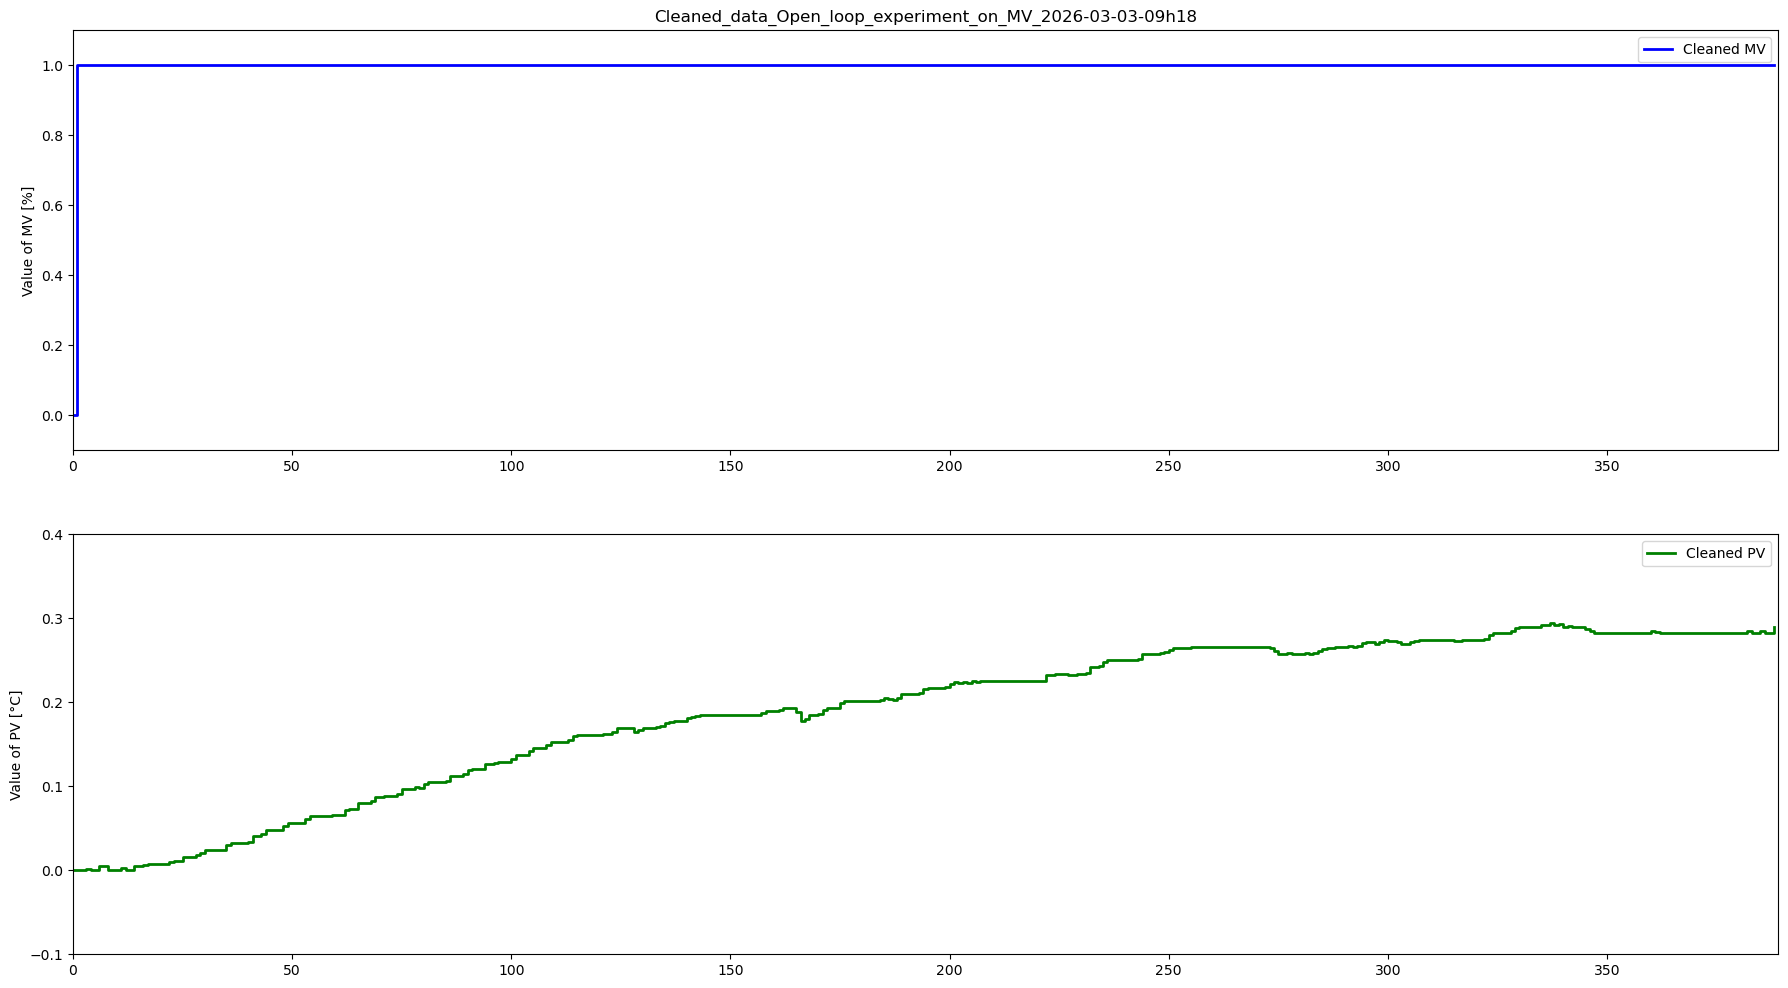

In [42]:
nameFile = 'Cleaned_data_Open_loop_experiment_on_MV_2026-03-03-09h18.txt'

titleName = nameFile.split('.')[0]    
data = pd.read_csv('Data/' + nameFile)

if 'MV' in nameFile:
    ExpVariable = 'MV'
    tm = data['tm'].values
    MVm = data['MVm'].values
    PVm = data['PVm'].values    
else:    
    ExpVariable = 'DV'
    tm = data['tm'].values
    DVm = data['DVm'].values 
    PVm = data['PVm'].values

Ts = 1
     
print(ExpVariable)   

plt.figure(figsize = (22,22))

fig, (ax1, ax2) = plt.subplots(2,1)
fig.set_figheight(12)
fig.set_figwidth(22)

if ExpVariable == 'MV':
    l1, = ax1.step([0,1],[0,100],'b-',linewidth=2,label='Cleaned MV',where='post')
    ax1.set_ylabel('Value of MV [%]')
    ax1.set_title(titleName)
    ax1.legend(loc='best')
    l1.set_data(tm,MVm)
    ax1.set_ylim(myRound(np.min(MVm),1)-0.1, myRound(np.max(MVm),1)+0.1)    
else:
    l1, = ax1.step([0,1],[0,100],'b-',linewidth=2,label='Cleaned DV',where='post')
    ax1.set_ylabel('Value of DV [%]')
    ax1.set_title(titleName)
    ax1.legend(loc='best')
    l1.set_data(tm,DVm)
    ax1.set_ylim(myRound(np.min(DVm),1)-0.1, myRound(np.max(DVm),1)+0.1)     

l2, = ax2.step([0,1],[0,100],'g-',linewidth=2,label='Cleaned PV',where='post')
ax2.set_ylabel('Value of PV [°C]')
ax2.legend(loc='best')
l2.set_data(tm,PVm)
ax2.set_ylim(myRound(np.min(PVm),0.1)-0.1, myRound(np.max(PVm),0.1)+0.1)

ax1.set_xlim(0, tm[-1]+1)
ax2.set_xlim(0, tm[-1]+1)



# Simulation 

## SOPDT and FOPDT optimal

In [43]:
Kp_FOPDTOPT =  0.3193162823001918
T_FOPDTOPT =  148.9436198091021
theta_FOPDTOPT = 20.83950535066936

Kp_SOPDTOPT = 0.32041709667754437
T1_SOPDTOPT = 149.5299167385502
T2_SOPDTOPT = 15.071947597079129
theta_SOPDTOPT = 4.000008096455504

PV_SOPDTOPT = SOPDT(MVm,Kp_SOPDTOPT,T1_SOPDTOPT,T2_SOPDTOPT,theta_SOPDTOPT,Ts)
PV_FOPDTOPT = FOPDT(MVm,Kp_FOPDTOPT,T_FOPDTOPT,theta_FOPDTOPT,Ts)

In [44]:
t1 = 68
t2 = 87

Tu = 19
Tg = 169

K = 0.28
a_graph = 0.07
Ts = 1


## Van der Grinden

In [45]:
Kp_SOPDTVDG = K
T1_SOPDTVDG = Tg*((3*a_graph*np.e-1)/(1+a_graph*np.e))
T2_SOPDTVDG = Tg*((1-np.e*a_graph)/(1+a_graph*np.e))
theta_SOPDTVDG = Tu-(T1_SOPDTVDG*T2_SOPDTVDG)/(T1_SOPDTVDG +3*T2_SOPDTVDG)

PV_SOPDTVDG = SOPDT(MVm,Kp_SOPDTVDG,T1_SOPDTVDG,T2_SOPDTVDG,theta_SOPDTVDG,Ts)

## Graphical Strejc model

a:  0.11242603550295859
b:  62.132352941176464


(0.0, 388.0)

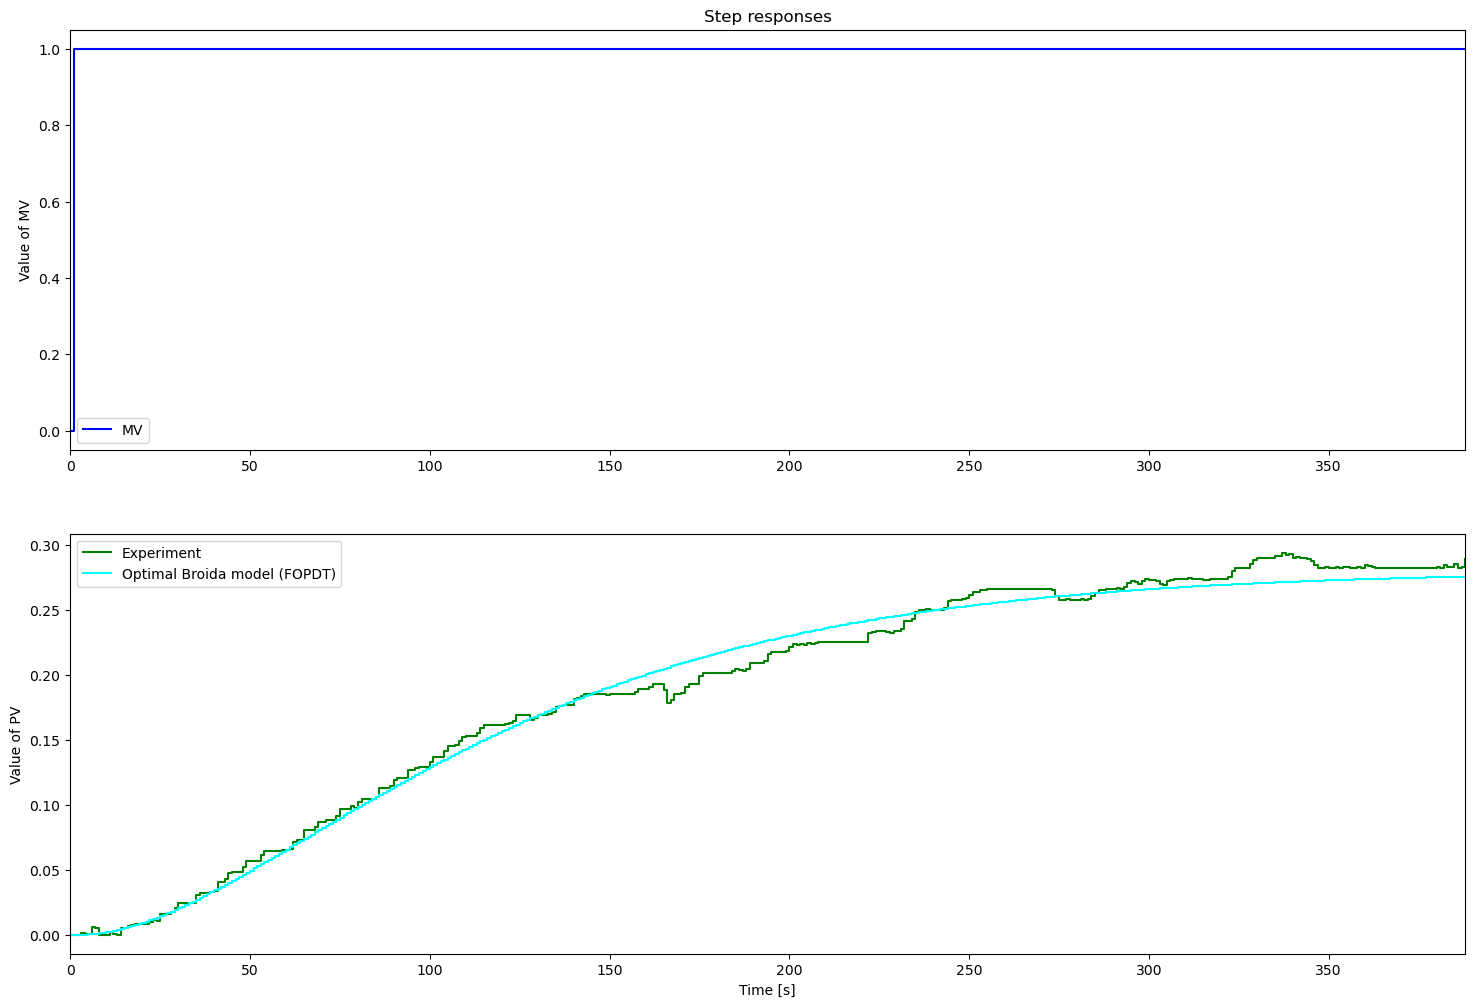

In [46]:
print("a: ", Tu/Tg)
a = 0.1
b = 2.72
print ("b: ", Tg/b)
T_Strejc = Tg/b
theta_Strejc = Tu - a*Tg


PV_FOPDTStrejc = SOPDT(MVm, K, T_Strejc, T_Strejc, theta_Strejc, Ts)

plt.figure(figsize = (18,12))

plt.subplot(2,1,1)
plt.step(tm,MVm,'b-',label='MV',where='post')
plt.ylabel('Value of MV')
plt.title('Step responses')
plt.legend(loc='best')
plt.xlim([0, np.max(tm)])   

plt.subplot(2,1,2)
plt.step(tm,PVm,'g-',label='Experiment',where='post')
plt.step(tm,PV_FOPDTStrejc,'cyan',label='Optimal Broida model (FOPDT)',where='post')
plt.ylabel('Value of PV')
plt.xlabel('Time [s]')
plt.legend(loc='best')  
plt.xlim([0, np.max(tm)])

# Broida Model 1 et 2

(0.0, 388.0)

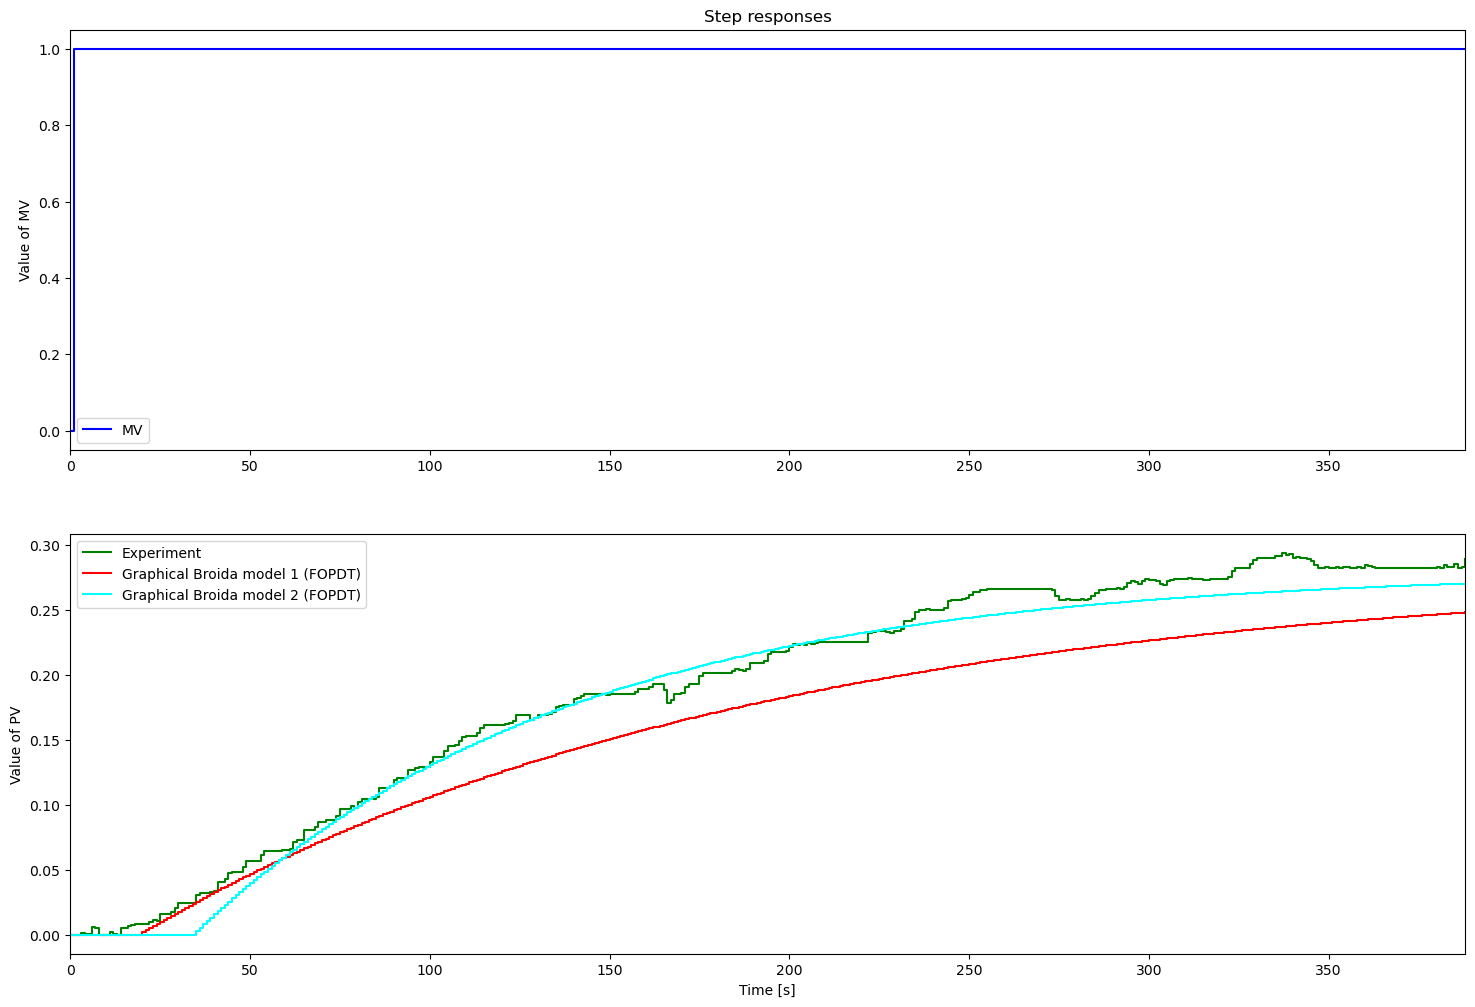

In [47]:

Kp_FOPDTBR = K
T_FOPDTBR =  Tg
theta_FOPDTBR = Tu

Kp_FOPDTBR2 =  K
T_FOPDTBR2 =  5.5*(t2-t1)
theta_FOPDTBR2 = 2.8*t1-1.8*t2

Kp_SOPDTVDG = K
T1_SOPDTVDG = Tg*(((3*a_graph*np.e)-1)/(1+ (a_graph*np.e)))
T2_SOPDTVDG = Tg*((1-(a_graph*np.e))/(1+ (a_graph*np.e)))
theta_SOPDTVDG = Tu - (T1_SOPDTVDG*T2_SOPDTVDG)/(T1_SOPDTVDG + (3*T2_SOPDTVDG))

Ts = 1


PV_FOPDTBR = FOPDT(MVm,Kp_FOPDTBR,T_FOPDTBR,theta_FOPDTBR,Ts)
PV_FOPDTBR2 = FOPDT(MVm,Kp_FOPDTBR2,T_FOPDTBR2,theta_FOPDTBR2,Ts)

plt.figure(figsize = (18,12))

plt.subplot(2,1,1)
plt.step(tm,MVm,'b-',label='MV',where='post')
plt.ylabel('Value of MV')
plt.title('Step responses')
plt.legend(loc='best')
plt.xlim([0, np.max(tm)])   

plt.subplot(2,1,2)
plt.step(tm,PVm,'g-',label='Experiment',where='post')
plt.step(tm,PV_FOPDTBR,'red',label='Graphical Broida model 1 (FOPDT)',where='post')
plt.step(tm,PV_FOPDTBR2,'cyan',label='Graphical Broida model 2 (FOPDT)',where='post')
plt.ylabel('Value of PV')
plt.xlabel('Time [s]')
plt.legend(loc='best')  
plt.xlim([0, np.max(tm)])

# Graph rassemblé

(0.0, 388.0)

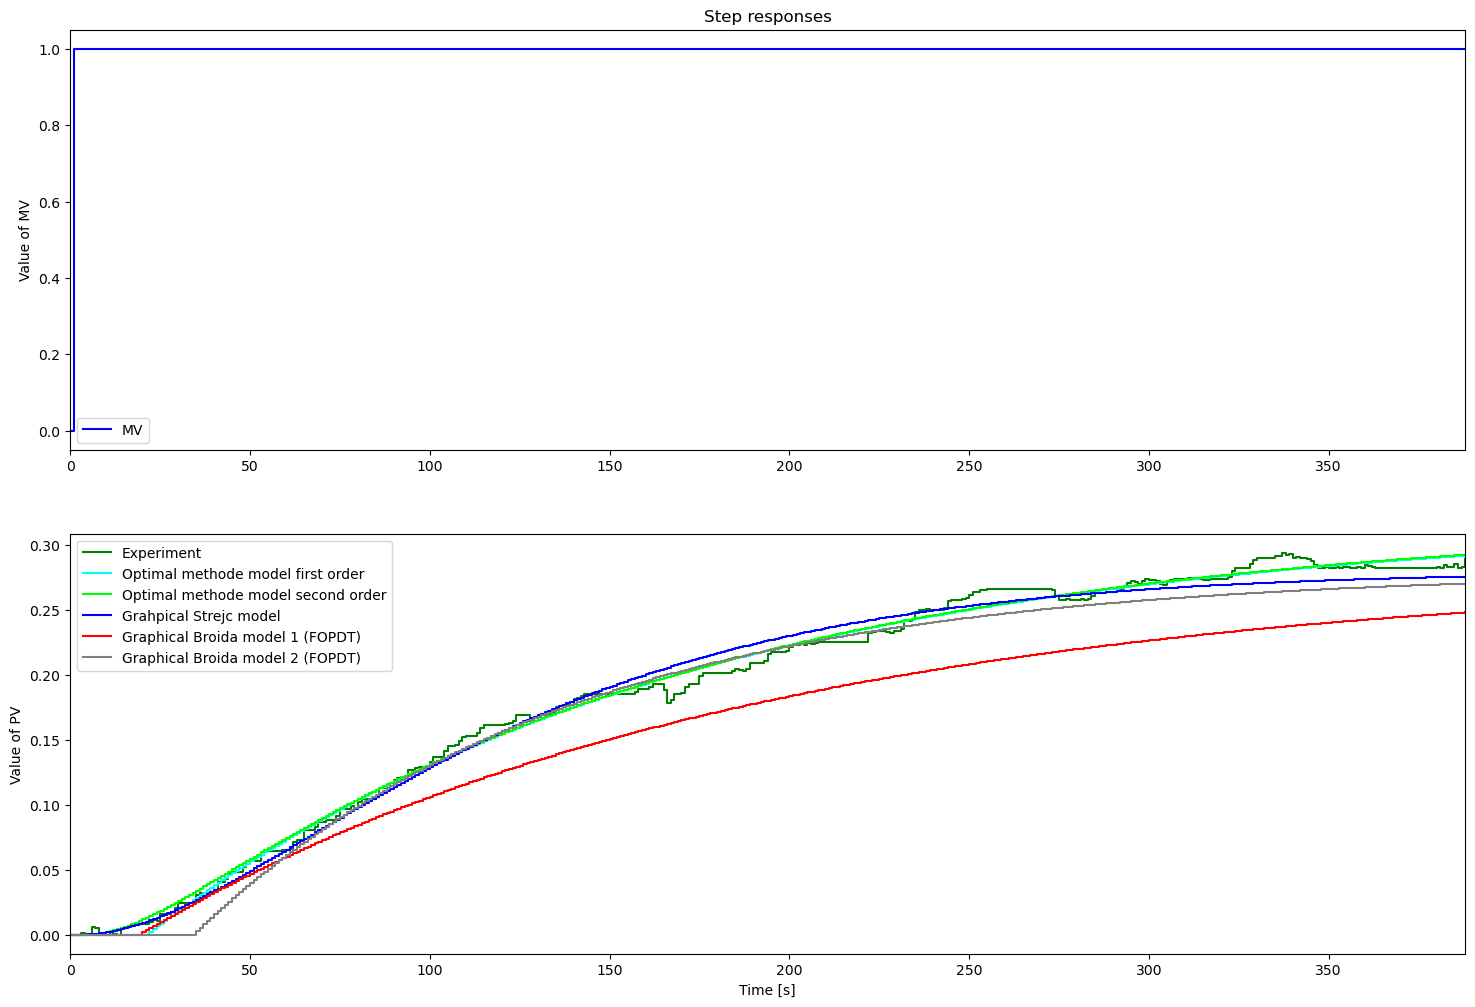

In [48]:
plt.figure(figsize = (18,12))

plt.subplot(2,1,1)
plt.step(tm,MVm,'b-',label='MV',where='post')
plt.ylabel('Value of MV')
plt.title('Step responses')
plt.legend(loc='best')
plt.xlim([0, np.max(tm)])   
plt.subplot(2,1,2)

plt.step(tm,PVm,'g-',label='Experiment',where='post')
plt.step(tm,PV_FOPDTOPT,'cyan',label='Optimal methode model first order',where='post')
plt.step(tm,PV_SOPDTOPT,'lime',label='Optimal methode model second order',where='post')
plt.step(tm,PV_FOPDTStrejc,'blue',label='Grahpical Strejc model',where='post')
#plt.step(tm,PV_SOPDTVDG,'lime',label='Graphical van der Grinten model (SOPDT)',where='post')
plt.step(tm,PV_FOPDTBR,'red',label='Graphical Broida model 1 (FOPDT)',where='post')
plt.step(tm,PV_FOPDTBR2,'grey',label='Graphical Broida model 2 (FOPDT)',where='post')

plt.ylabel('Value of PV')
plt.xlabel('Time [s]')
plt.legend(loc='best')  
plt.xlim([0, np.max(tm)])

# Bode Diagrame

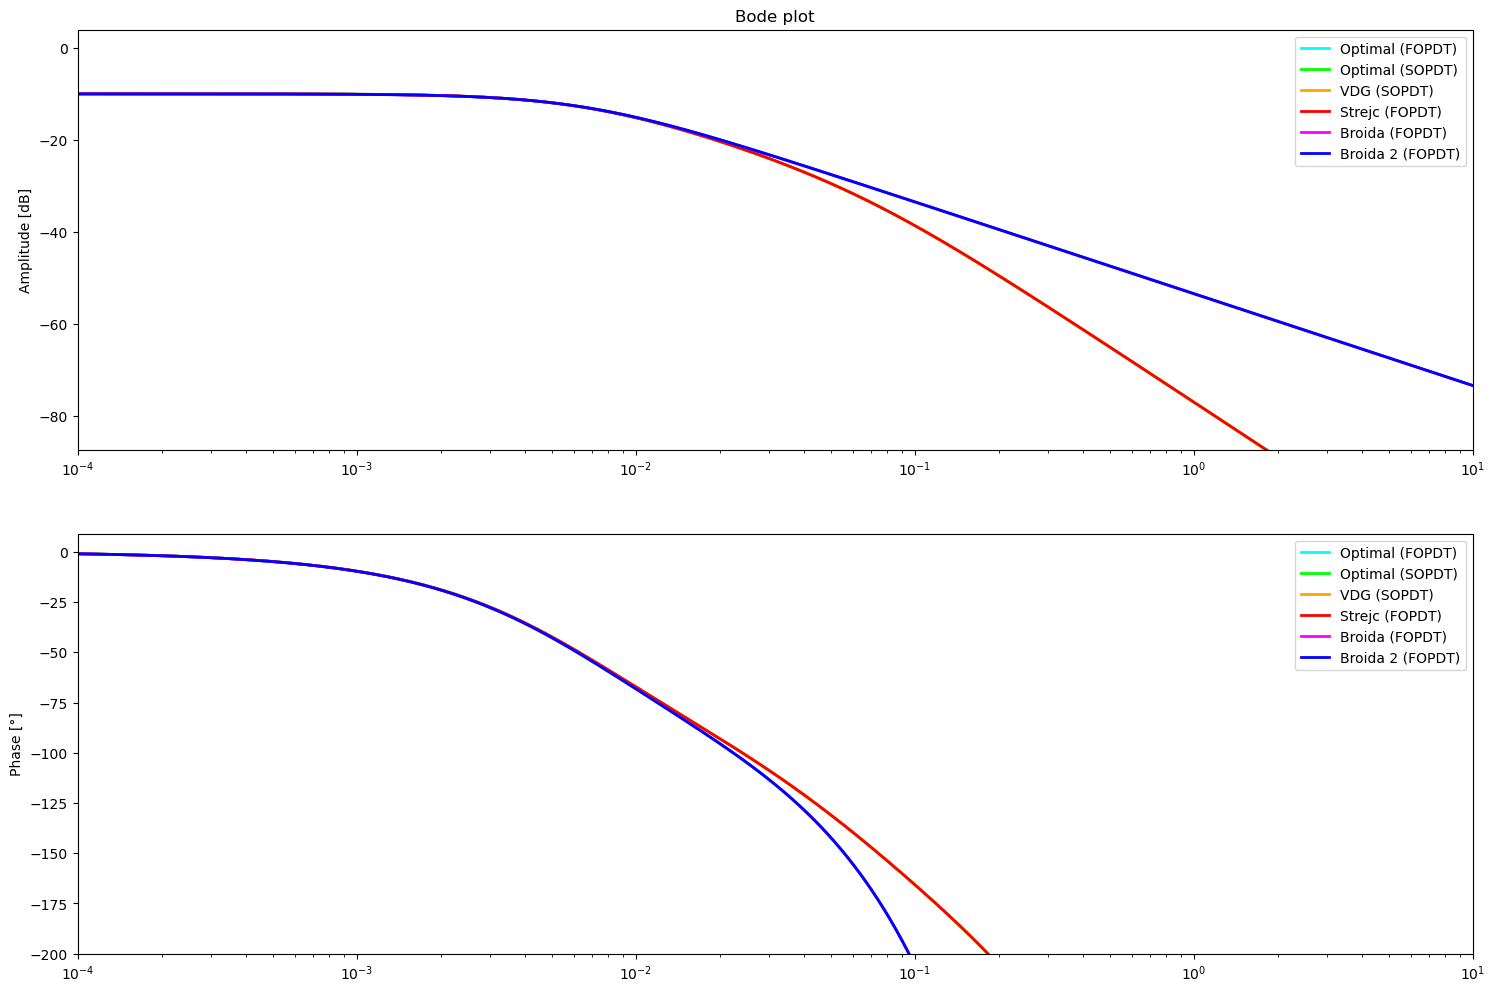

In [49]:
# Frequency response
P_FOPDTOPT = Process({})
P_FOPDTOPT.parameters['Kp']    = Kp_FOPDTOPT
P_FOPDTOPT.parameters['Tlag1'] = T_FOPDTOPT
P_FOPDTOPT.parameters['theta'] = theta_FOPDTOPT

# Frequency response
P_SOPDTOPT = Process({})
P_SOPDTOPT.parameters['Kp']    = Kp_SOPDTOPT
P_SOPDTOPT.parameters['Tlag1'] = T1_SOPDTOPT
P_SOPDTOPT.parameters['Tlag2'] = T2_SOPDTOPT
P_SOPDTOPT.parameters['theta'] = theta_SOPDTOPT

# Frequency response
P_SOPDTVDG = Process({})
P_SOPDTVDG.parameters['Kp']    = Kp_SOPDTOPT
P_SOPDTVDG.parameters['Tlag1'] = T1_SOPDTOPT
P_SOPDTVDG.parameters['Tlag2'] = T2_SOPDTOPT
P_SOPDTVDG.parameters['theta'] = theta_SOPDTOPT

# Frequency response
P_FOPDTStrejc = Process({})
P_FOPDTStrejc.parameters['Kp']    = Kp_SOPDTOPT
P_FOPDTStrejc.parameters['Tlag1'] = T1_SOPDTOPT
P_FOPDTStrejc.parameters['Tlag2'] = T2_SOPDTOPT
P_FOPDTStrejc.parameters['theta'] = theta_SOPDTOPT

# Frequency response
P_FOPDTBR = Process({})
P_FOPDTBR.parameters['Kp']    = Kp_FOPDTOPT
P_FOPDTBR.parameters['Tlag1'] = T_FOPDTOPT
P_FOPDTBR.parameters['theta'] = theta_FOPDTOPT

# Frequency response
P_FOPDTBR2 = Process({})
P_FOPDTBR2.parameters['Kp']    = Kp_FOPDTOPT
P_FOPDTBR2.parameters['Tlag1'] = T_FOPDTOPT
P_FOPDTBR2.parameters['theta'] = theta_FOPDTOPT

omega = np.logspace(-4, 1, 10000)
Ps_FOPDTOPT    = Bode(P_FOPDTOPT,    omega, False)
Ps_SOPDTOPT    = Bode(P_SOPDTOPT,    omega, False)
Ps_SOPDTVDG    = Bode(P_SOPDTVDG,    omega, False)
Ps_FOPDTStrejc = Bode(P_FOPDTStrejc, omega, False)
Ps_FOPDTBR     = Bode(P_FOPDTBR,     omega, False)
Ps_FOPDTBR2    = Bode(P_FOPDTBR2,    omega, False)

plt.figure(figsize=(18, 12))

plt.subplot(2, 1, 1)
gain_min = np.min(20*np.log10(np.abs(Ps_FOPDTOPT)/5))
gain_max = np.max(20*np.log10(np.abs(Ps_FOPDTOPT)*5))
plt.semilogx(omega, 20*np.log10(np.abs(Ps_FOPDTOPT)),    'cyan',    linewidth=2, label='Optimal (FOPDT)')
plt.semilogx(omega, 20*np.log10(np.abs(Ps_SOPDTOPT)),    'lime',    linewidth=2, label='Optimal (SOPDT)')
plt.semilogx(omega, 20*np.log10(np.abs(Ps_SOPDTVDG)),    'orange',  linewidth=2, label='VDG (SOPDT)')
plt.semilogx(omega, 20*np.log10(np.abs(Ps_FOPDTStrejc)), 'red',     linewidth=2, label='Strejc (FOPDT)')
plt.semilogx(omega, 20*np.log10(np.abs(Ps_FOPDTBR)),     'magenta', linewidth=2, label='Broida (FOPDT)')
plt.semilogx(omega, 20*np.log10(np.abs(Ps_FOPDTBR2)),    'blue',    linewidth=2, label='Broida 2 (FOPDT)')
plt.xlim([np.min(omega), np.max(omega)])
plt.ylim([gain_min, gain_max])
plt.ylabel('Amplitude [dB]')
plt.title('Bode plot')
plt.legend(loc='best')

plt.subplot(2, 1, 2)
ph_min = np.min((180/np.pi)*np.unwrap(np.angle(Ps_FOPDTOPT))) - 10
ph_max = np.max((180/np.pi)*np.unwrap(np.angle(Ps_FOPDTOPT))) + 10
plt.semilogx(omega, (180/np.pi)*np.unwrap(np.angle(Ps_FOPDTOPT)),    'cyan',    linewidth=2, label='Optimal (FOPDT)')
plt.semilogx(omega, (180/np.pi)*np.unwrap(np.angle(Ps_SOPDTOPT)),    'lime',    linewidth=2, label='Optimal (SOPDT)')
plt.semilogx(omega, (180/np.pi)*np.unwrap(np.angle(Ps_SOPDTVDG)),    'orange',  linewidth=2, label='VDG (SOPDT)')
plt.semilogx(omega, (180/np.pi)*np.unwrap(np.angle(Ps_FOPDTStrejc)), 'red',     linewidth=2, label='Strejc (FOPDT)')
plt.semilogx(omega, (180/np.pi)*np.unwrap(np.angle(Ps_FOPDTBR)),     'magenta', linewidth=2, label='Broida (FOPDT)')
plt.semilogx(omega, (180/np.pi)*np.unwrap(np.angle(Ps_FOPDTBR2)),    'blue',    linewidth=2, label='Broida 2 (FOPDT)')
plt.xlim([np.min(omega), np.max(omega)])
plt.ylim([np.max([ph_min, -200]), ph_max])
plt.ylabel('Phase [°]')
plt.legend(loc='best')

# DV

MV


(0.0, 238.0)

<Figure size 2200x2200 with 0 Axes>

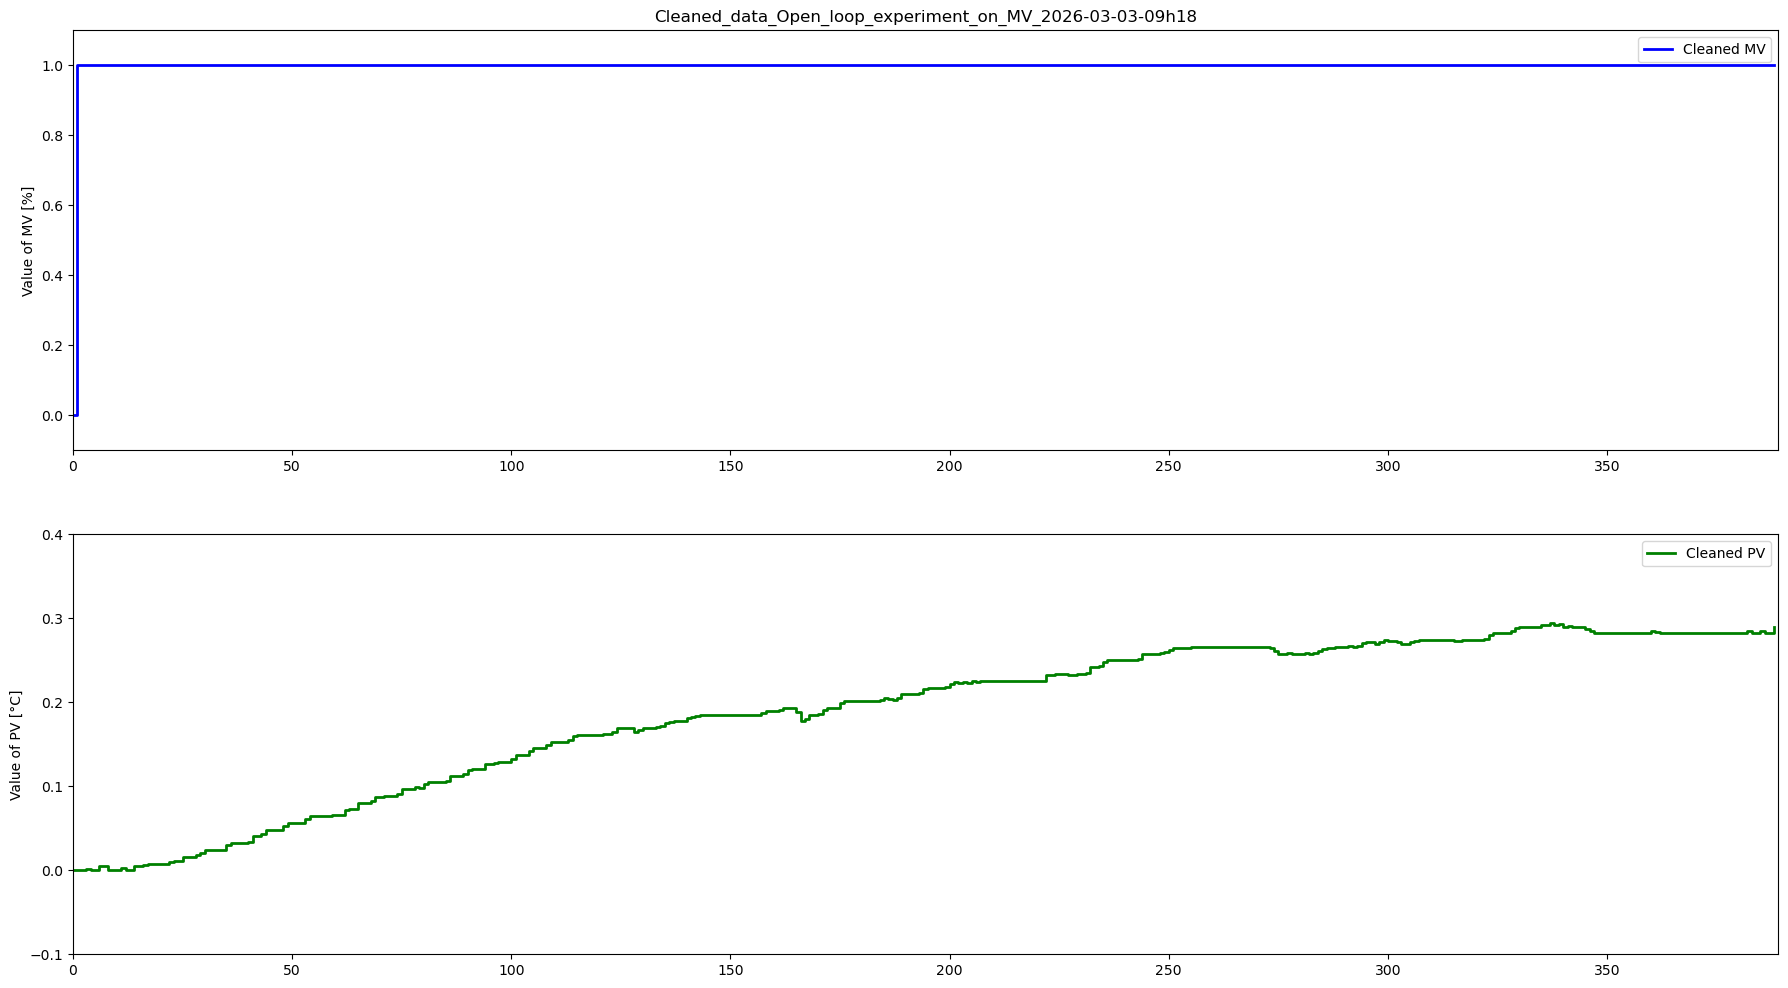

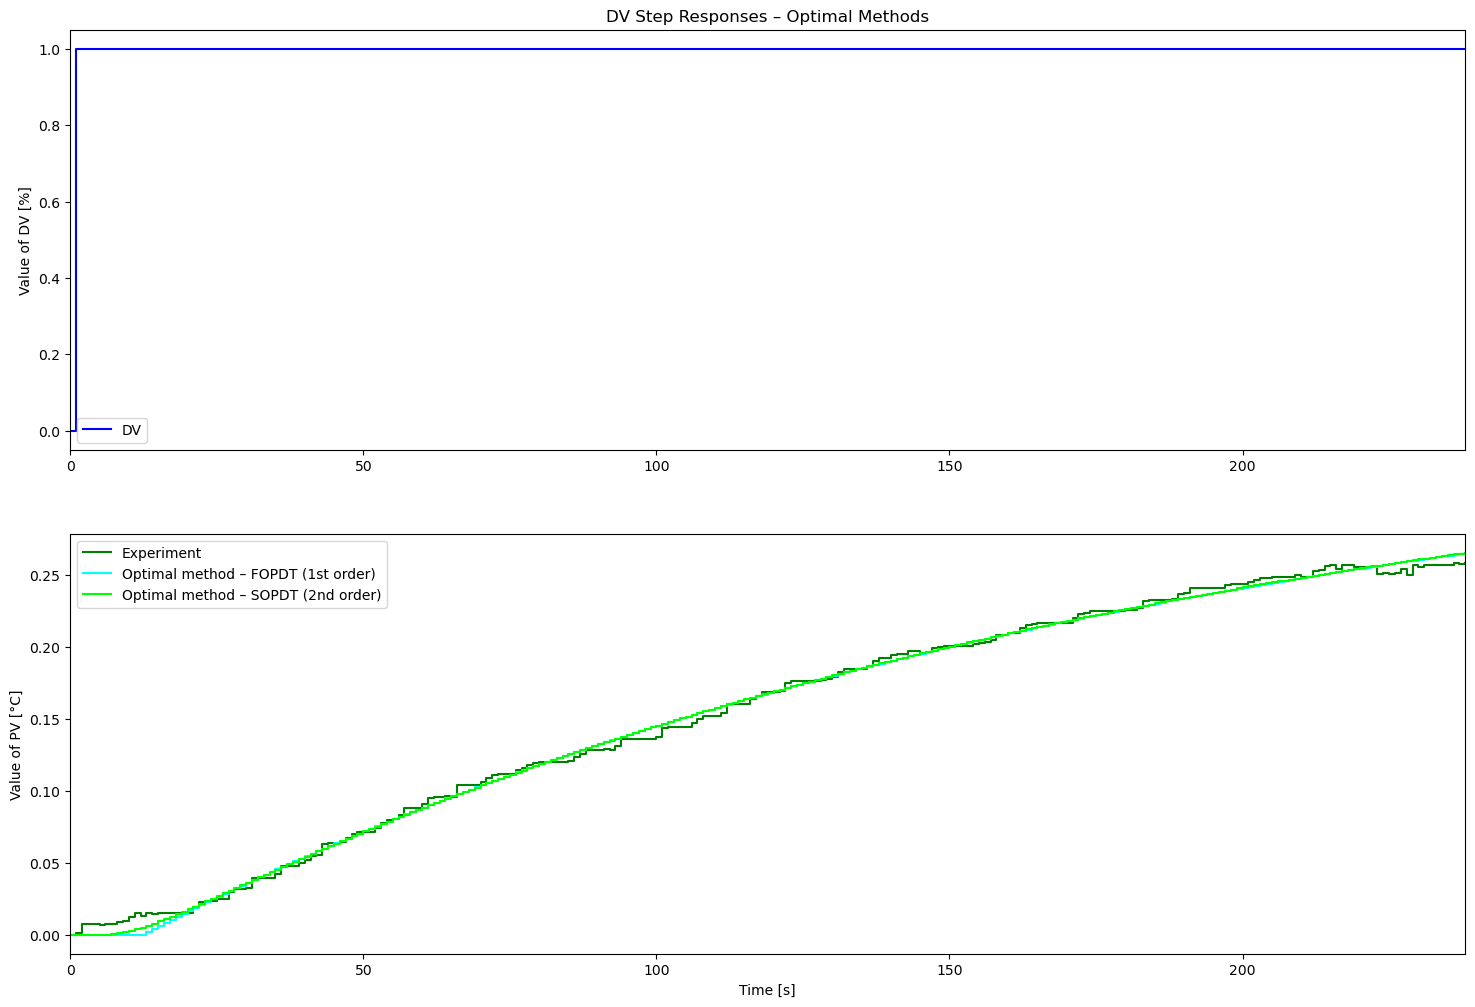

: 

In [ ]:
nameFile_DV = 'Cleaned_data_Open_loop_experiment_on_DV_2026-03-05-21h14.txt'
data_DV = pd.read_csv('Data/' + nameFile_DV)
tm_DV  = data_DV['tm'].values
DVm    = data_DV['DVm'].values
PVm_DV = data_DV['PVm'].values
     
print(ExpVariable)   

plt.figure(figsize = (22,22))

fig, (ax1, ax2) = plt.subplots(2,1)
fig.set_figheight(12)
fig.set_figwidth(22)

if ExpVariable == 'MV':
    l1, = ax1.step([0,1],[0,100],'b-',linewidth=2,label='Cleaned MV',where='post')
    ax1.set_ylabel('Value of MV [%]')
    ax1.set_title(titleName)
    ax1.legend(loc='best')
    l1.set_data(tm,MVm)
    ax1.set_ylim(myRound(np.min(MVm),1)-0.1, myRound(np.max(MVm),1)+0.1)    
else:
    l1, = ax1.step([0,1],[0,100],'b-',linewidth=2,label='Cleaned DV',where='post')
    ax1.set_ylabel('Value of DV [%]')
    ax1.set_title(titleName)
    ax1.legend(loc='best')
    l1.set_data(tm,DVm)
    ax1.set_ylim(myRound(np.min(DVm),1)-0.1, myRound(np.max(DVm),1)+0.1)     

l2, = ax2.step([0,1],[0,100],'g-',linewidth=2,label='Cleaned PV',where='post')
ax2.set_ylabel('Value of PV [°C]')
ax2.legend(loc='best')
l2.set_data(tm,PVm)
ax2.set_ylim(myRound(np.min(PVm),0.1)-0.1, myRound(np.max(PVm),0.1)+0.1)

ax1.set_xlim(0, tm[-1]+1)
ax2.set_xlim(0, tm[-1]+1)

Ts_DV = 1
# First order (FOPDT)
Kp_DV_FOPDTOPT    = 0.36273769970295805
T_DV_FOPDTOPT     = 171.36277670168337
theta_DV_FOPDTOPT = 11.497422823838285

# Second order (SOPDT)
Kp_DV_SOPDTOPT    = 0.36255533921521593
T1_DV_SOPDTOPT    = 170.7770252576119
T2_DV_SOPDTOPT    = 6.12569974510096
theta_DV_SOPDTOPT = 5.431848706357882


# --- Simulate DV optimal models ---
PV_DV_FOPDTOPT = FOPDT(DVm, Kp_DV_FOPDTOPT, T_DV_FOPDTOPT, theta_DV_FOPDTOPT, Ts_DV)
PV_DV_SOPDTOPT = SOPDT(DVm, Kp_DV_SOPDTOPT, T1_DV_SOPDTOPT, T2_DV_SOPDTOPT, theta_DV_SOPDTOPT, Ts_DV)

# --- Plot ---
plt.figure(figsize=(18, 12))

plt.subplot(2, 1, 1)
plt.step(tm_DV, DVm, 'b-', label='DV', where='post')
plt.ylabel('Value of DV [%]')
plt.title('DV Step Responses – Optimal Methods')
plt.legend(loc='best')
plt.xlim([0, np.max(tm_DV)])

plt.subplot(2, 1, 2)
plt.step(tm_DV, PVm_DV,         'g-',   label='Experiment',                        where='post')
plt.step(tm_DV, PV_DV_FOPDTOPT, 'cyan', label='Optimal method – FOPDT (1st order)', where='post')
plt.step(tm_DV, PV_DV_SOPDTOPT, 'lime', label='Optimal method – SOPDT (2nd order)', where='post')
plt.ylabel('Value of PV [°C]')
plt.xlabel('Time [s]')
plt.legend(loc='best')
plt.xlim([0, np.max(tm_DV)])